#### Imports

In [185]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *

## Asset and Fitting Date Choices

In [73]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

# print('Commodities:', commodity_close_prices.columns.tolist())
# print('ETFs:', etf_close_prices.columns.tolist())
# print('Universe:', universe_close_prices.columns.tolist())

In [74]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

# from pandas import option_context
# with option_context('display.max_colwidth', None):
#     display(asset_names_df)

In [75]:
rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
rebal_dates[:5]

['20181231', '20190131', '20190304', '20190402', '20190502']

In [76]:
asset_names_df['us_equity'].tolist()

['SPDR S&P 500 ETF',
 'Invesco QQQ Trust',
 'iShares Russell 2000 ETF',
 'SPDR Dow Jones Industrial Average ETF',
 'Energy Select Sector SPDR',
 'Financial Select Sector SPDR',
 'Utilities Select Sector SPDR',
 'Industrial Select Sector SPDR',
 'Health Care Select Sector SPDR',
 'Technology Select Sector SPDR',
 'Materials Select Sector SPDR',
 'Consumer Discretionary Select Sector SPDR',
 'Consumer Staples Select Sector SPDR',
 'iShares S&P 500 Growth ETF',
 'iShares S&P 500 Value ETF',
 'iShares Russell 2000 Growth ETF',
 'iShares Russell 2000 Value ETF',
 'iShares Russell Mid-Cap ETF',
 'iShares Micro-Cap ETF']

## Load KAMA+MSR and KMRF Models

In [77]:
CONFIG = KMRF_Training_Config(
    asset_name= asset_names_df['us_equity'].tolist()[0], # Update this to desired asset
    classification_type='original',
    use_data_type='master',
    end_date=rebal_dates[0], # Update this to desired rebal data
    feature_window_size=1,
    feature_asset_classes=[],
    cross_asset_specific=[], 
    use_boruta_selection=True,
    use_consensus_selection=False
)
kama_msr_file_path = f"saved_models/KAMA_MSR/{CONFIG.get_asset_class()}/{CONFIG.get_date_ranges()['end_date']}/{CONFIG.get_asset_name()}_KAMA-MSR_4-regimes.pkl"
kmrf_file_path = f"saved_models/KMRF_new/original/{CONFIG.get_asset_class()}/{CONFIG.get_asset_name().replace(' ', '_')}_KMRF_model.pkl"
with open(kama_msr_file_path, 'rb') as f:
    kama_msr = pickle.load(f)
with contextlib.redirect_stdout(io.StringIO()):
    kmrf = KMRF.load_model(kmrf_file_path)

## Build HMM Posterior Regime Probailities

In [78]:
def get_forward_regime_probs(kama_msr: KAMA_MSR, kmrf: KMRF, alpha: float = 0.75): # confidence weight on likelihood vs prior)    
    with contextlib.redirect_stdout(io.StringIO()):
        ########## Fit exponential certainty decay to regime autocorrelations ##########
        regime_autocorrs = {}
        for k in range(1, 21):
            regime_autocorrs[k] = kama_msr.regime_labels.autocorr(lag=k)
            
        regime_autocorrs = pd.Series(regime_autocorrs)

        from scipy.optimize import curve_fit

        def exp_decay(delta, a, lambda_decay):
            return a * np.exp(-lambda_decay * delta)
        popt, pcov = curve_fit(exp_decay, regime_autocorrs.index, regime_autocorrs.values, p0=(0.5, 0.05))
        a_fit, lambda_decay_fit = popt
        
        ################################################################################
        
        transition_results = kama_msr.regime_transition_analysis(in_depth=False) 
        P = transition_results[1]['transition_matrix'] + 1 # Add 1 for Laplace Smoothing
        P = P.apply(lambda row: row / row.sum(), axis=1)
        eigvals, eigvecs = np.linalg.eig(P.T)
        steady_state = eigvecs[:, np.isclose(eigvals, 1)]
        steady_state = steady_state[:, 0].real
        steady_state /= steady_state.sum()
        
        kmrf_likelihood_t1 = kmrf.predict(test_or_val='val').iloc[0].reset_index(drop=True).rename('')

        prior_t1 = P.loc[kama_msr.regime_labels[-1]].reset_index(drop=True).rename('') # P(regime_t+1 | regime_t)
        
        unnormalized = prior_t1.pow(1-alpha).multiply(kmrf_likelihood_t1.pow(alpha))
        posterior_t1 = unnormalized / unnormalized.sum()
    
        forward_probs = np.zeros((21, 4))
        uncertainty_factor = 1 - a_fit*np.exp(-lambda_decay_fit*1)
        forward_probs[0] = (1 - uncertainty_factor) * posterior_t1 + uncertainty_factor * steady_state
        for i in range(1, 21):
            delta = i+1
            uncertainty_factor = 1 - a_fit*np.exp(-lambda_decay_fit*delta)
            probs_raw_delta = forward_probs[i-1] @ P.values
            forward_probs[i] = (1 - uncertainty_factor) * probs_raw_delta + uncertainty_factor * steady_state
    
    day_t = kama_msr.regime_labels.index[-1].strftime('%Y-%m-%d')
    new_index = kmrf.raw_ohlc.loc[day_t:][1:22].index
    df = pd.DataFrame(forward_probs, index=new_index, columns=range(0, 4)).rename_axis('regime', axis=1)
    df['uncertainty_factor'] = [1- a_fit*np.exp(-lambda_decay_fit*delta) for delta in range(0, 21)]
    return df

forward_probs = get_forward_regime_probs(kama_msr, kmrf)

In [80]:
df = kama_msr.regime_labels.to_frame('regime').join(kama_msr.returns.rename('return')).dropna()
return_characterics_by_regime = df.groupby('regime')['return'].agg(['count', 'mean', 'std', 'skew', lambda ser: ser.kurtosis()])\
    .rename(columns={'<lambda_0>': 'kurtosis'})
mean_by_regime = return_characterics_by_regime['mean']
var_by_regime = return_characterics_by_regime['std'] ** 2
return_characterics_by_regime

,count,mean,std,skew,kurtosis
regime,,,,,
0,4548,0.000473,0.008434,-0.345051,1.535855
1,1128,0.000494,0.012768,0.059126,0.074286
2,44,-0.008867,0.032651,0.161388,-0.388633
3,303,-0.002151,0.031149,0.266104,1.332219


## Distribution Fitting with Statistical Significance Testing

We use statistical tests to determine which distribution is appropriate:
- **Normal**: Neither skewness nor excess kurtosis is significant
- **Skew-Normal**: Skewness is significant, but excess kurtosis is not
- **Student-t**: Excess kurtosis is significant, but skewness is not  
- **Skewed-t**: Both skewness and excess kurtosis are significant

Statistical significance is determined using bootstrap-based confidence intervals at 95% level.

In [ ]:
def test_significance(returns: pd.Series, alpha: float = 0.05) -> Dict[str, bool]:
    """
    Test statistical significance of skewness and excess kurtosis using hypothesis tests.
    
    H0: skewness = 0 (symmetric distribution)
    H0: excess kurtosis = 0 (normal tail behavior)
        
    Parameters
    ----------
    returns : pd.Series
        Return data
    alpha : float
        Significance level (default 0.05 for 95% confidence)
        
    Returns
    -------
    dict
        {'skew_significant': bool, 'kurt_significant': bool, 
         'skew': float, 'kurt': float, 'p_skew': float, 'p_kurt': float, 'n': int}
    """
    n = len(returns)
    skew_val = returns.skew()
    kurt_val = returns.kurtosis()  # Excess kurtosis
    
    # For large samples (n >= 150), use analytical Z-test
    # Standard error of skewness: SE(skew) = sqrt(6/n)
    # Standard error of excess kurtosis: SE(kurt) = sqrt(24/n)
    if n >= 150:
        se_skew = np.sqrt(6 / n)
        se_kurt = np.sqrt(24 / n)
        
        # Test statistic: Z = (statistic - 0) / SE
        z_skew = skew_val / se_skew
        z_kurt = kurt_val / se_kurt
        
        # Two-tailed p-value from standard normal
        p_skew = 2 * (1 - scipy_stats.norm.cdf(abs(z_skew)))
        p_kurt = 2 * (1 - scipy_stats.norm.cdf(abs(z_kurt)))
        
        # Reject H0 if p < alpha
        skew_significant = p_skew < alpha
        kurt_significant = p_kurt < alpha
        
    else:
        # For small samples (n < 150), use bootstrap hypothesis test
        # Under H0: skew=0, kurt=0, we center the bootstrap distribution at 0
        n_boot = 2000
        boot_skews = []
        boot_kurts = []
        
        np.random.seed(42)
        for _ in range(n_boot):
            boot_sample = returns.sample(n=n, replace=True)
            boot_skews.append(boot_sample.skew())
            boot_kurts.append(boot_sample.kurtosis())
        
        boot_skews = np.array(boot_skews)
        boot_kurts = np.array(boot_kurts)
        
        # Center bootstrap distributions at 0 (under H0)
        boot_skews_centered = boot_skews - np.mean(boot_skews)
        boot_kurts_centered = boot_kurts - np.mean(boot_kurts)
        
        # P-value = proportion of bootstrap samples more extreme than observed
        # Two-tailed test: count both tails
        p_skew = np.mean(np.abs(boot_skews_centered) >= abs(skew_val))
        p_kurt = np.mean(np.abs(boot_kurts_centered) >= abs(kurt_val))
        
        # Reject H0 if p < alpha
        skew_significant = p_skew < alpha
        kurt_significant = p_kurt < alpha
    
    return {
        'skew_significant': skew_significant,
        'kurt_significant': kurt_significant,
        'skew': skew_val,
        'kurt': kurt_val,
        'p_skew': p_skew,
        'p_kurt': p_kurt,
        'n': n
    }


In [221]:
def fit_distribution(returns: pd.Series) -> Dict:
    """
    Fit appropriate distribution based on statistical significance tests.
    
    Decision tree:
    1. Test skewness and kurtosis for statistical significance
    2. Choose distribution accordingly:
       - Normal: Neither significant
       - Skew-Normal: Only skewness significant
       - Student-t: Only kurtosis significant
       - Normal Inverse Gaussian: Both significant

    Parameters
    ----------
    returns : pd.Series
        Historical returns for a regime
        
    Returns
    -------
    dict
        Distribution parameters and metadata
    """
    # Test significance
    sig_test = test_significance(returns)
    
    mu = returns.mean()
    sigma = returns.std()
    skew_val = sig_test['skew']
    kurt_val = sig_test['kurt']
    p_skew = sig_test['p_skew']
    p_kurt = sig_test['p_kurt']
    n = sig_test['n']
    
    skew_sig = sig_test['skew_significant']
    kurt_sig = sig_test['kurt_significant']
    
    print(f"  N={n}, μ={mu:.5f}, σ={sigma:.5f}")
    print(f"  skew={skew_val:.3f} (p={p_skew:.4f}){'***' if p_skew<0.01 else '**' if p_skew<0.05 else ''}")
    print(f"  kurt={kurt_val:.3f} (p={p_kurt:.4f}){'***' if p_kurt<0.01 else '**' if p_kurt<0.05 else ''}")
    
    # Case 1: Neither skew nor kurtosis significant → Normal
    if not skew_sig and not kurt_sig:
        print(f"  → Normal distribution")
        return {
            'distribution': 'normal',
            'params': (mu, sigma),
            'loc': mu,
            'scale': sigma,
            'method': 'analytical',
            'empirical': {'mean': mu, 'std': sigma, 'skew': skew_val, 'kurt': kurt_val, 'n': n}
        }
    
    # Case 2: Only skewness significant → Skew-Normal
    elif skew_sig and not kurt_sig:
        # Fit skew-normal using method of moments
        # For skew-normal: solve for 'a' parameter from empirical skewness
        def skew_objective(a):
            delta = a / np.sqrt(1 + a**2)
            theoretical_skew = ((4 - np.pi) / 2) * (delta**3) / (1 - 2*delta**2/np.pi)**(3/2)
            return (theoretical_skew - skew_val)**2
        
        result = minimize(skew_objective, x0=np.sign(skew_val) * 2, bounds=[(-20, 20)], method='L-BFGS-B')
        a = result.x[0]
        
        # Adjust loc and scale for skew-normal
        delta = a / np.sqrt(1 + a**2)
        omega = sigma / np.sqrt(1 - 2*delta**2/np.pi)
        xi = mu - omega * delta * np.sqrt(2/np.pi)
        
        print(f"  → Skew-Normal: a={a:.4f}")
        return {
            'distribution': 'skewnorm',
            'params': (a, xi, omega),
            'a': a,
            'loc': xi,
            'scale': omega,
            'method': 'moments',
            'empirical': {'mean': mu, 'std': sigma, 'skew': skew_val, 'kurt': kurt_val, 'n': n}
        }
    
    # Case 3: Only kurtosis significant → Student-t
    elif not skew_sig and kurt_sig:
        # Estimate df from excess kurtosis
        # For Student-t: E[excess kurtosis] = 6/(df-4) for df > 4
        if kurt_val > 0.1:
            df = max(2.5, min(30, 6 / kurt_val + 4))
        else:
            df = 30
        
        # For Student-t: Var = scale^2 * df/(df-2)
        # So scale = sigma * sqrt((df-2)/df)
        if df > 2:
            scale_t = sigma * np.sqrt((df - 2) / df)
        else:
            scale_t = sigma
        
        print(f"  → Student-t: df={df:.2f}")
        return {
            'distribution': 'student_t',
            'params': (df, mu, scale_t),
            'df': df,
            'loc': mu,
            'scale': scale_t,
            'method': 'moments',
            'empirical': {'mean': mu, 'std': sigma, 'skew': skew_val, 'kurt': kurt_val, 'n': n}
        }
    
    # Case 4: Both significant → Normal Inverse Gaussian (NIG)
    else:
        print(f"  → Normal Inverse Gaussian (both skew and kurt significant)")
        
        try:
            # Use scipy's robust MLE fitting for NIG
            # NIG params: (a, b, loc, scale) where a>0 controls tails, |b|<a controls skew
            a, b, loc, scale = norminvgauss.fit(returns.values)
            
            # Validate fitted parameters
            if a <= 0 or abs(b) >= a or scale <= 0 or not np.isfinite(loc):
                raise ValueError(f"Invalid NIG params: a={a:.4f}, b={b:.4f}, loc={loc:.5f}, scale={scale:.5f}")
            
            print(f"     MLE converged: a={a:.4f}, b={b:.4f}, loc={loc:.5f}, scale={scale:.5f}")
            
            return {
                'distribution': 'norminvgauss',
                'params': (a, b, loc, scale),
                'a': a,
                'b': b,
                'loc': loc,
                'scale': scale,
                'method': 'MLE',
                'empirical': {'mean': mu, 'std': sigma, 'skew': skew_val, 'kurt': kurt_val, 'n': n}
            }
            
        except Exception as e:
            print(f"     NIG MLE failed ({e}), falling back to Student-t")
            # Fallback to Student-t if NIG fitting fails
            df = max(3.0, min(15, 6 / kurt_val + 4) if kurt_val > 0 else 10)
            scale_t = sigma * np.sqrt((df - 2) / df)
            
            print(f"     Using Student-t: df={df:.2f}, scale={scale_t:.5f}")
            
            return {
                'distribution': 'student_t',
                'params': (df, mu, scale_t),
                'df': df,
                'loc': mu,
                'scale': scale_t,
                'method': 'moments_fallback',
                'empirical': {'mean': mu, 'std': sigma, 'skew': skew_val, 'kurt': kurt_val, 'n': n}
            }
        

In [222]:
def sample_from_distribution(dist_params: Dict, size: int = 1, max_return: float = 0.5) -> np.ndarray:
    """
    Sample from fitted distribution with safeguards against extreme values.
    
    Parameters
    ----------
    dist_params : dict
        Distribution parameters from fit_distribution()
    size : int
        Number of samples to generate
    max_return : float
        Maximum absolute daily return allowed (default 0.5 = 50%)
        
    Returns
    -------
    np.ndarray
        Random samples, clipped to reasonable bounds
    """
    dist_type = dist_params['distribution']
    params = dist_params['params']
    
    # Add validation before sampling
    if dist_type == 'normal':
        loc, scale = params
        if not (np.isfinite(loc) and np.isfinite(scale) and scale > 0):
            raise ValueError(f"Invalid normal params: loc={loc}, scale={scale}")
        samples = np.random.normal(loc, scale, size=size)
    
    elif dist_type == 'skewnorm':
        a, loc, scale = params
        if not (np.isfinite(a) and np.isfinite(loc) and np.isfinite(scale) and scale > 0):
            raise ValueError(f"Invalid skewnorm params: a={a}, loc={loc}, scale={scale}")
        samples = skewnorm.rvs(a, loc=loc, scale=scale, size=size)
    
    elif dist_type == 'student_t':
        df, loc, scale = params
        if not (np.isfinite(df) and df > 0 and np.isfinite(loc) and np.isfinite(scale) and scale > 0):
            raise ValueError(f"Invalid student_t params: df={df}, loc={loc}, scale={scale}")
        samples = t.rvs(df, loc=loc, scale=scale, size=size)
    
    elif dist_type == 'norminvgauss':
        a, b, loc, scale = params
        
        # Strict validation for NIG
        if not (np.isfinite(a) and a > 0):
            raise ValueError(f"Invalid a={a}, must be > 0 and finite")
        if not (np.isfinite(b) and abs(b) < a):
            raise ValueError(f"Invalid b={b}, must satisfy |b| < a={a}")
        if not (np.isfinite(scale) and scale > 0):
            raise ValueError(f"Invalid scale={scale}, must be > 0 and finite")
        if not np.isfinite(loc):
            raise ValueError(f"Invalid loc={loc}, must be finite")
        
        try:
            samples = norminvgauss.rvs(a, b, loc=loc, scale=scale, size=size)
        except Exception as e:
            raise ValueError(f"norminvgauss.rvs failed with params a={a}, b={b}, loc={loc}, scale={scale}: {e}")
    
    elif dist_type == 'skewt':
        df, loc, scale, gamma = params
        
        # Strict validation for skewed-t
        if not (np.isfinite(df) and df > 2):
            raise ValueError(f"Invalid df={df}, must be > 2 and finite")
        if not (np.isfinite(scale) and scale > 0):
            raise ValueError(f"Invalid scale={scale}, must be > 0 and finite")
        if not (np.isfinite(loc)):
            raise ValueError(f"Invalid loc={loc}, must be finite")
        if not (np.isfinite(gamma) and abs(gamma) < 1):
            raise ValueError(f"Invalid gamma={gamma}, must be in (-1, 1)")
        
        try:
            samples = skewt.rvs(df, loc, scale, gamma, size=size)
        except Exception as e:
            raise ValueError(f"skewt.rvs failed with params df={df}, loc={loc}, scale={scale}, gamma={gamma}: {e}")
    
    else:
        raise ValueError(f"Unknown distribution type: {dist_type}")
    
    # Clip extreme values to prevent numerical issues
    # Daily returns outside [-50%, +50%] are unrealistic for most assets
    samples = np.clip(samples, -max_return, max_return)
    
    # Final safety check
    if not np.all(np.isfinite(samples)):
        n_invalid = np.sum(~np.isfinite(samples))
        raise ValueError(f"Generated {n_invalid} non-finite samples from {dist_type} distribution")
    
    return samples


In [223]:
def fit_distributions_by_regime(regime_labels: pd.Series, returns: pd.Series) -> Dict[int, Dict]:
    """
    Fit distributions for each regime with statistical significance testing.
    
    Parameters
    ----------
    regime_labels : pd.Series
        Regime assignments
    returns : pd.Series
        Daily returns
        
    Returns
    -------
    dict
        {regime_id: distribution_params}
    """
    df = regime_labels.to_frame('regime').join(returns.rename('return')).dropna()
    
    distributions = {}
    print("\n" + "="*80)
    print("FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)")
    print("="*80)
    
    for regime in sorted(df['regime'].unique()):
        print(f"\nRegime {regime}:")
        regime_returns = df[df['regime'] == regime]['return']
        distributions[regime] = fit_distribution(regime_returns)
    
    print("\n" + "="*80)
    return distributions


In [224]:
def validate_distribution_params(regime_distributions: Dict[int, Dict]) -> pd.DataFrame:
    """
    Validate and summarize fitted distribution parameters.
    
    Returns DataFrame showing which regimes have valid parameters.
    """
    validation = []
    
    for regime, params in regime_distributions.items():
        dist_type = params['distribution']
        
        if dist_type == 'normal':
            loc, scale = params['params']
            valid = scale > 0 and np.isfinite(loc) and np.isfinite(scale)
            
        elif dist_type == 'skewnorm':
            a, loc, scale = params['params']
            valid = scale > 0 and all(np.isfinite([a, loc, scale]))
            
        elif dist_type == 'student_t':
            df, loc, scale = params['params']
            valid = df > 0 and scale > 0 and all(np.isfinite([df, loc, scale]))
        
        elif dist_type == 'norminvgauss':
            a, b, loc, scale = params['params']
            valid = (a > 0 and 
                    abs(b) < a and
                    scale > 0 and 
                    all(np.isfinite([a, b, loc, scale])))
            
        elif dist_type == 'skewt':
            df, loc, scale, gamma = params['params']
            valid = (df > 2 and 
                    scale > 0 and 
                    abs(gamma) < 1 and 
                    all(np.isfinite([df, loc, scale, gamma])))
        else:
            valid = False
        
        validation.append({
            'regime': regime,
            'distribution': dist_type,
            'valid': valid,
            'loc': params.get('loc'),
            'scale': params.get('scale'),
            'df': params.get('df', np.nan),
            'a': params.get('a', np.nan),
            'b': params.get('b', np.nan),
            'gamma': params.get('gamma', np.nan),
            'n_obs': params['empirical']['n']
        })
    
    df = pd.DataFrame(validation)
    
    print("\n" + "="*80)
    print("DISTRIBUTION PARAMETER VALIDATION")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80)
    
    if not df['valid'].all():
        invalid = df[~df['valid']]
        print(f"\n⚠️  WARNING: {len(invalid)} regime(s) have invalid parameters!")
        print(invalid.to_string(index=False))
    else:
        print("\n✓ All distributions have valid parameters")
    
    return df


In [225]:
def simulate_21day_paths_adaptive(
    forward_probs: pd.DataFrame,
    regime_distributions: Dict[int, Dict],
    transition_matrix: pd.DataFrame,
    n_simulations: int = 10000,
    random_seed: int = 1010
) -> np.ndarray:
    """
    Simulate 21-day paths with adaptive distributions and Bayesian regime updates.
    
    Parameters
    ----------
    forward_probs : pd.DataFrame
        Forward regime probabilities (21 x 4) from Bayesian HMM
    regime_distributions : dict
        {regime_id: dist_params} from fit_distributions_by_regime()
    transition_matrix : pd.DataFrame
        Regime transition matrix (4 x 4)
    n_simulations : int
        Number of Monte Carlo paths
    random_seed : int
        Random seed for reproducibility
        
    Returns
    -------
    np.ndarray
        Cumulative returns (n_simulations, 21)
    """
    np.random.seed(random_seed)
    
    P = transition_matrix.values  # (4, 4)
    forward_probs_array = forward_probs.iloc[:, :4].values  # (21, 4)
    
    simulated_returns = np.zeros((n_simulations, 21))
    
    for sim in range(n_simulations):
        # Sample initial regime from Bayesian posterior at t+1
        current_probs = forward_probs_array[0].copy()
        current_regime = np.random.choice(4, p=current_probs)
        
        for day in range(21):
            # Draw return from current regime's fitted distribution
            dist_params = regime_distributions[current_regime]
            daily_return = sample_from_distribution(dist_params, size=1)[0]
            simulated_returns[sim, day] = daily_return
            
            # Bayesian update for next day's regime probabilities
            if day < 20:
                # HMM prior from forward propagation
                hmm_prior = forward_probs_array[day + 1]
                
                # Transition likelihood conditioned on current regime
                transition_likelihood = P[current_regime]
                
                # Bayesian posterior: prior × likelihood
                unnormalized = hmm_prior * transition_likelihood
                current_probs = unnormalized / unnormalized.sum()
                
                # Sample next regime
                current_regime = np.random.choice(4, p=current_probs)
    
    # Cumulative returns
    # cumulative_returns = np.cumsum(simulated_returns, axis=1)
    df = pd.DataFrame(simulated_returns).T
    df.rename(index=lambda d: f'Day t+{d+1}', inplace=True)
    df.rename(columns=lambda i: f'Sim {i+1}', inplace=True)
    return df


In [226]:
# Fit distributions for each regime
regime_distributions = fit_distributions_by_regime(kama_msr.regime_labels, kama_msr.returns)

# Validate fitted distributions before simulation
validation_df = validate_distribution_params(regime_distributions)


FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:
  N=4548, μ=0.00047, σ=0.00843
  skew=-0.345 (p=0.0000)***
  kurt=1.536 (p=0.0000)***
  → Normal Inverse Gaussian (both skew and kurt significant)
     MLE converged: a=1.1804, b=-0.1513, loc=0.00165, scale=0.00913

Regime 1:
  N=1128, μ=0.00049, σ=0.01277
  skew=0.059 (p=0.4175)
  kurt=0.074 (p=0.6106)
  → Normal distribution

Regime 2:
  N=44, μ=-0.00887, σ=0.03265
  skew=0.161 (p=0.5275)
  kurt=-0.389 (p=0.3045)
  → Normal distribution

Regime 3:
  N=303, μ=-0.00215, σ=0.03115
  skew=0.266 (p=0.0586)
  kurt=1.332 (p=0.0000)***
  → Student-t: df=8.50


DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale       df      a         b  gamma  n_obs
      0 norminvgauss   True  0.001654 0.009131      NaN 1.1804 -0.151301    NaN   4548
      1       normal   True  0.000494 0.012768      NaN    NaN       NaN    NaN   1128
      2       normal   True -0.008867 0.032651      NaN    NaN       NaN

### Run Simulations

In [194]:
# Get transition matrix
with contextlib.redirect_stdout(io.StringIO()):
    transition_results = kama_msr.regime_transition_analysis(in_depth=False)
P = transition_results[1]['transition_matrix'] + 1  # Laplace smoothing
P = P.apply(lambda row: row / row.sum(), axis=1)

# Simulate with normal distributions (baseline)
regime_stats_normal = {
    'mean_by_regime': return_characterics_by_regime['mean'],
    'std_by_regime': return_characterics_by_regime['std']
}

# Simulate with adaptive distributions (improved)
simulated_returns_adaptive = simulate_21day_paths_adaptive(
    forward_probs,
    regime_distributions,
    P,
    n_simulations=10000
)

In [ ]:
true_path = kmrf.raw_ohlc.droplevel(0, axis=1)['close']\
    .loc[kama_msr.returns.index[-1]:][:22].pct_change().dropna()\
    .add(1).cumprod().sub(1).to_frame().rename(columns={'close': 'True Path'})

sim_paths = simulated_returns_adaptive.add(1).cumprod(axis=0).subtract(1)
sim_paths.index = true_path.index

true_and_sims = pd.concat([true_path, sim_paths], axis=1)

Text(0, 0.5, 'Cumulative Return')

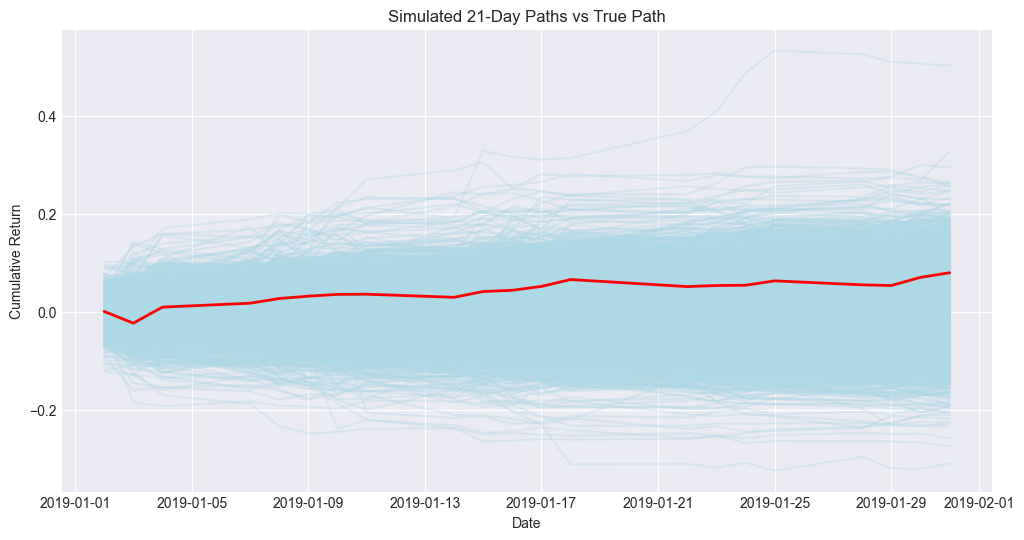

In [199]:
# plot simulated paths vs true path
plt.figure(figsize=(12, 6))
for col in true_and_sims.columns[1:]:
    plt.plot(true_and_sims.index, true_and_sims[col], color='lightblue', alpha=0.3)
plt.plot(true_and_sims.index, true_and_sims['True Path'], color='red', linewidth=2, label='True Path')
plt.title('Simulated 21-Day Paths vs True Path')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')

(array([  1.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,   2.,
          1.,   3.,   2.,   6.,   4.,   5.,   8.,   7.,  15.,  24.,  25.,
         29.,  61.,  59.,  90.,  88., 146., 157., 206., 264., 336., 337.,
        393., 475., 491., 567., 600., 596., 587., 516., 516., 496., 445.,
        428., 360., 278., 286., 233., 172., 119., 118., 105.,  73.,  57.,
         47.,  43.,  27.,  18.,  20.,  10.,  15.,   6.,   5.,   2.,   4.,
          2.,   0.,   3.,   2.,   3.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-0.30915311, -0.30103081, -0.29290851, -0.28478622, -0.27666392,
        -0.26854163, -0.26041933, -0.25229703, -0.24417474, -0.23605244,
        -0.22793015, -0.21980785, -0.21168555, -0.20356326, -0.19544096,
        -0.18731867, -0.17919637, -0.17107407, -0.16295178, -0.15482948,
        -0.14670719, -0.13

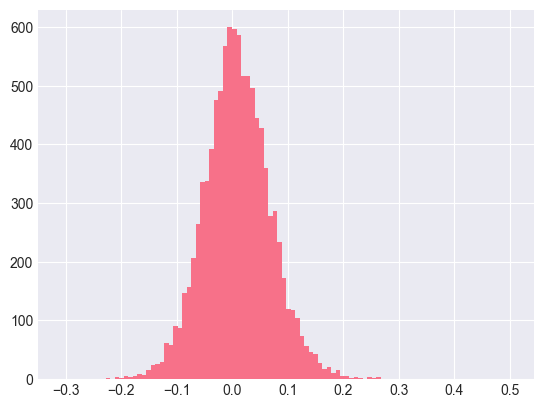

In [219]:
# histogram of simulated paths cumulative returns
plt.hist(sim_paths.iloc[-1], bins=100)

---

## Using the BayesianForwardSimulator Class

The complete implementation has been refactored into `bayesian_forward_simulator.py`.


BAYESIAN FORWARD SIMULATION - FULL ANALYSIS

[1/5] Computing forward regime probabilities...
✓ Computed 21-day forward probabilities

[2/5] Fitting regime-specific distributions...

FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:
  N=4548, μ=0.00047, σ=0.00843
  skew=-0.345 (p=0.0000)***
  kurt=1.536 (p=0.0000)***
  → Normal Inverse Gaussian (both skew and kurt significant)
     MLE converged: a=1.1804, b=-0.1513, loc=0.00165, scale=0.00913

Regime 1:
  N=1128, μ=0.00049, σ=0.01277
  skew=0.059 (p=0.4175)
  kurt=0.074 (p=0.6106)
  → Normal distribution

Regime 2:
✓ Computed 21-day forward probabilities

[2/5] Fitting regime-specific distributions...

FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:
  N=4548, μ=0.00047, σ=0.00843
  skew=-0.345 (p=0.0000)***
  kurt=1.536 (p=0.0000)***
  → Normal Inverse Gaussian (both skew and kurt significant)
     MLE converged: a=1.1804, b=-0.1513, loc=0.00165, scale=0.00913

Regime 1:
  N=1128, μ=0.00049,

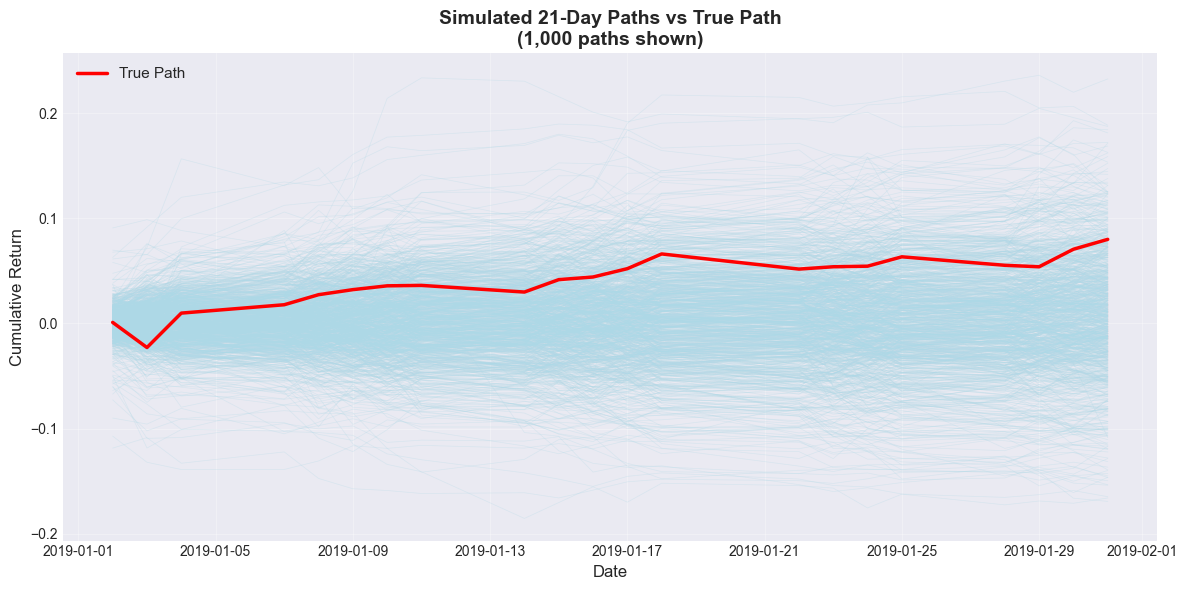

Generating terminal distribution...


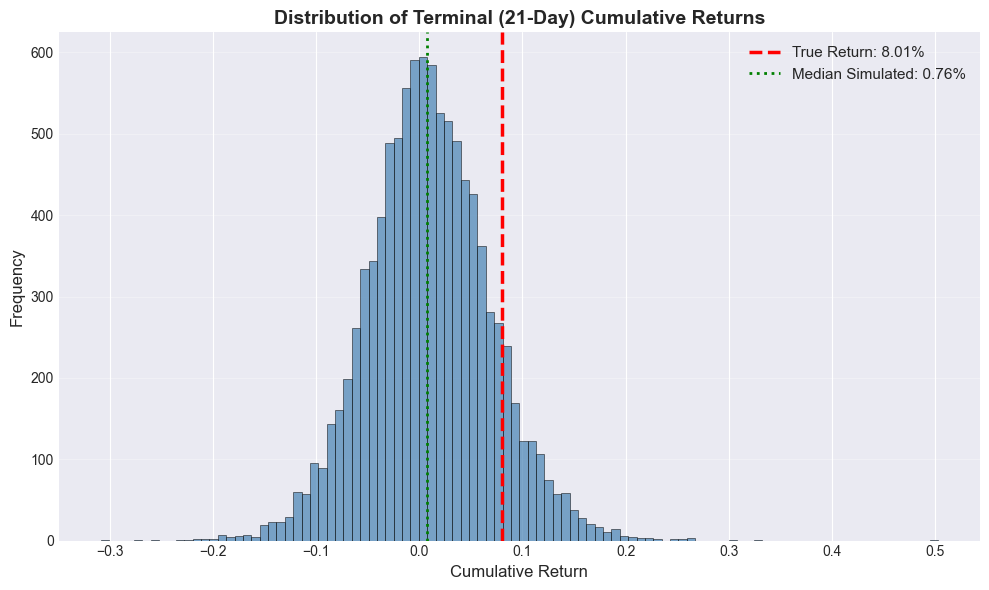


ANALYSIS COMPLETE


In [227]:
from bayesian_forward_simulator import BayesianForwardSimulator

# Create simulator instance
simulator = BayesianForwardSimulator(
    kama_msr=kama_msr,
    kmrf=kmrf,
    n_days=21,
    alpha_confidence=0.75,
    significance_level=0.05
)

# Run full analysis pipeline
results = simulator.run_full_analysis(
    n_simulations=10000,
    random_seed=1010,
    plot_paths=True,
    plot_terminal=True,
    n_paths_to_plot=1000
)

In [231]:
results.keys()

dict_keys(['forward_probs', 'regime_distributions', 'validation', 'simulated_returns', 'summary_stats'])

In [232]:
results['simulated_returns']

,Sim 1,Sim 2,Sim 3,Sim 4,Sim 5,Sim 6,Sim 7,Sim 8,Sim 9,Sim 10,...,Sim 9991,Sim 9992,Sim 9993,Sim 9994,Sim 9995,Sim 9996,Sim 9997,Sim 9998,Sim 9999,Sim 10000
Day t+1,-0.004707,-0.006356,-0.004250,-0.012137,-0.002293,0.006266,0.009766,-0.004178,-0.002447,-0.006842,...,0.013482,-0.006872,0.011588,0.007041,0.002505,0.006441,0.062827,0.007822,0.012532,-0.004603
Day t+2,-0.015502,0.004188,-0.019214,0.019320,-0.012131,-0.000514,0.011608,0.006347,-0.000440,0.006843,...,0.033718,-0.019323,0.018992,0.008485,0.039216,0.006193,0.027129,0.005532,0.008676,-0.023413
Day t+3,-0.031847,-0.000566,-0.000170,0.009277,-0.002342,-0.006115,-0.024493,0.012726,-0.000557,-0.013250,...,-0.005343,-0.021998,0.007851,0.002808,0.019688,0.015455,0.026032,0.008504,-0.014437,0.022968
Day t+4,0.008264,0.004825,0.014485,-0.010199,-0.009462,0.000743,-0.009414,-0.005924,-0.007515,-0.002385,...,-0.011224,-0.019766,0.015188,0.005091,0.003861,0.007188,0.013017,-0.004138,0.000453,-0.001969
Day t+5,0.016389,-0.009591,-0.007753,-0.031639,-0.015204,0.011616,0.000316,0.002728,-0.003626,0.029558,...,0.025036,-0.002485,0.016584,0.008375,-0.008608,-0.003987,-0.003212,-0.004942,0.003950,-0.017401
Day t+6,-0.002744,0.026392,0.000268,0.001243,0.007759,0.010899,-0.021989,0.015442,-0.008923,0.015883,...,-0.035261,0.008273,0.000963,-0.007439,0.020942,-0.022073,0.006688,0.012184,-0.032348,0.007314
Day t+7,0.000427,0.002209,-0.002526,0.001564,0.017473,-0.000763,0.002302,-0.003136,0.003083,0.012936,...,0.022698,0.007979,0.004815,0.014245,-0.008735,0.010262,0.015278,-0.005317,0.009790,-0.002847
Day t+8,-0.011584,-0.020401,-0.000420,0.001928,0.026360,-0.008005,0.015268,0.000956,-0.003942,0.014349,...,-0.030034,0.005384,-0.006481,0.011824,0.009139,0.008666,0.003476,0.009488,-0.007011,0.000162
Day t+9,-0.007974,0.000286,-0.019439,-0.015305,-0.006056,0.012270,0.015829,0.021057,-0.000241,-0.006612,...,-0.005128,0.021032,0.003434,-0.011201,0.020871,-0.016861,0.009683,0.002545,0.031152,0.006660
Day t+10,-0.011677,-0.008727,-0.005255,-0.005903,0.005347,0.001945,-0.007505,-0.016294,0.008066,0.006734,...,-0.027114,-0.006273,-0.013469,-0.001005,0.028800,0.018515,0.007606,0.025555,-0.009335,-0.007929


In [228]:
# Access individual results
forward_probs = results['forward_probs']
regime_distributions = results['regime_distributions']
simulated_returns = results['simulated_returns']  # Daily returns (not cumulative)
summary_stats = results['summary_stats']

print("\nSimulated Returns Shape:", simulated_returns.shape)
print(f"({simulator.n_days} days × {simulated_returns.shape[1]} simulations)")
print("\nFirst 5 days, first 3 simulations:")
print(simulated_returns.iloc[:5, :3])


Simulated Returns Shape: (21, 10000)
(21 days × 10000 simulations)

First 5 days, first 3 simulations:
            Sim 1     Sim 2     Sim 3
Day t+1 -0.004707 -0.006356 -0.004250
Day t+2 -0.015502  0.004188 -0.019214
Day t+3 -0.031847 -0.000566 -0.000170
Day t+4  0.008264  0.004825  0.014485
Day t+5  0.016389 -0.009591 -0.007753


### Alternative: Step-by-Step Usage

You can also run each step individually for more control:


FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:
  N=4548, μ=0.00047, σ=0.00843
  skew=-0.345 (p=0.0000)***
  kurt=1.536 (p=0.0000)***
  → Normal Inverse Gaussian (both skew and kurt significant)
     MLE converged: a=1.1804, b=-0.1513, loc=0.00165, scale=0.00913

Regime 1:
  N=1128, μ=0.00049, σ=0.01277
  skew=0.059 (p=0.4175)
  kurt=0.074 (p=0.6106)
  → Normal distribution

Regime 2:
  N=44, μ=-0.00887, σ=0.03265
  skew=0.161 (p=0.5275)
  kurt=-0.389 (p=0.3045)
  → Normal distribution

Regime 3:
  N=303, μ=-0.00215, σ=0.03115
  skew=0.266 (p=0.0586)
  kurt=1.332 (p=0.0000)***
  → Student-t: df=8.50


DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale       df      a         b  n_obs
      0 norminvgauss   True  0.001654 0.009131      NaN 1.1804 -0.151301   4548
      1       normal   True  0.000494 0.012768      NaN    NaN       NaN   1128
      2       normal   True -0.008867 0.032651      NaN    NaN       NaN     44
      3    st

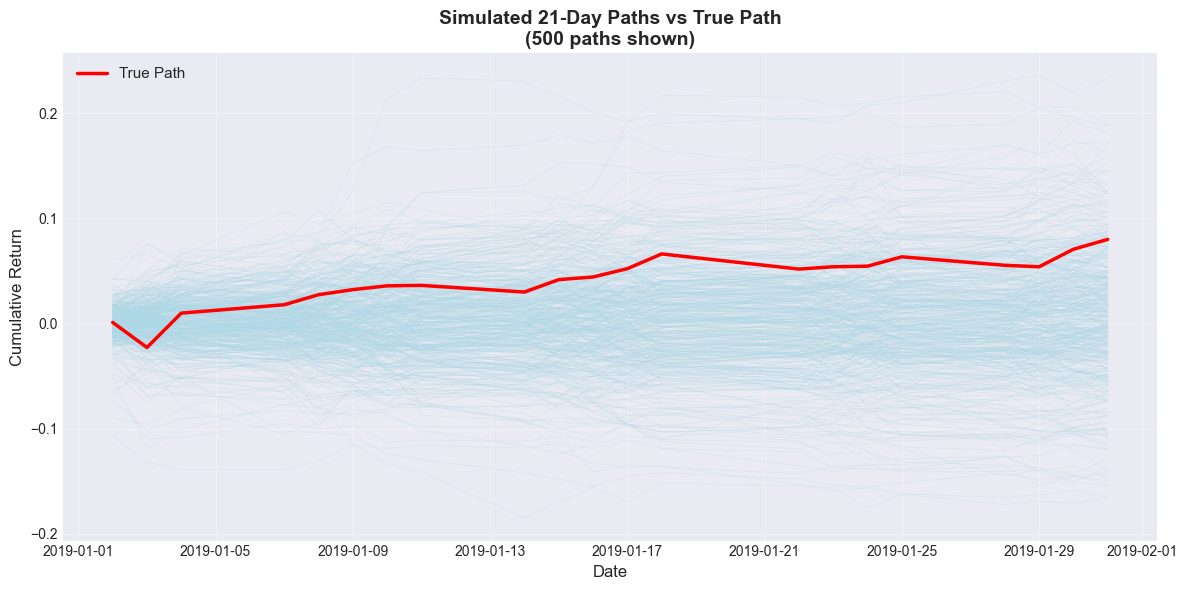

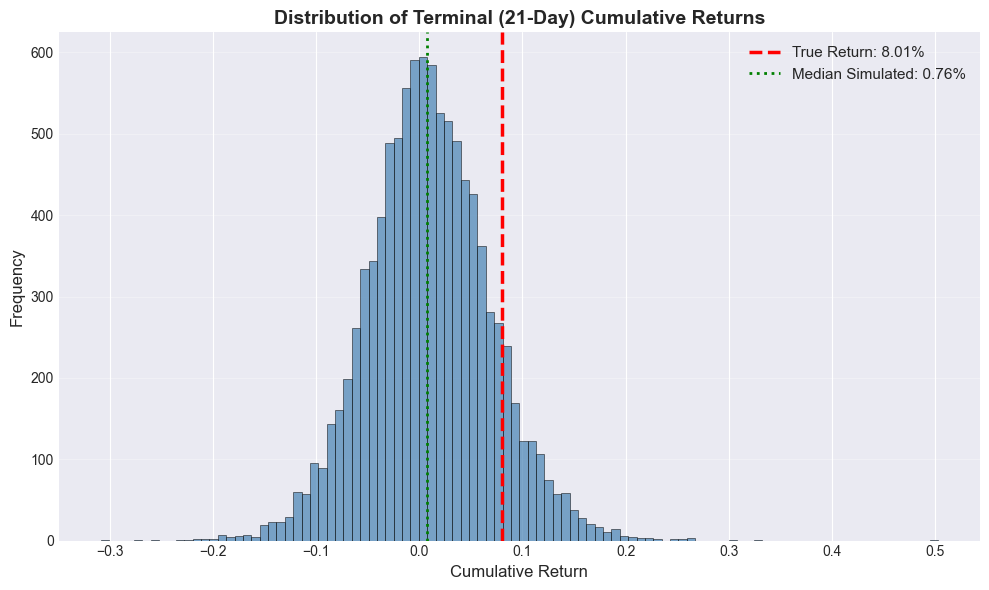

In [229]:
# Step-by-step approach
sim = BayesianForwardSimulator(kama_msr, kmrf, n_days=21)

# 1. Compute forward probabilities
forward_probs = sim.compute_forward_regime_probs()

# 2. Fit regime distributions
regime_dists = sim.fit_regime_distributions()

# 3. Validate parameters
validation = sim.validate_distributions()

# 4. Run simulations
daily_returns = sim.simulate(n_simulations=10000, random_seed=1010)

# 5. Analyze results
stats = sim.summary_statistics()

# 6. Plot results
sim.plot_simulated_paths(n_paths_to_plot=500)
sim.plot_terminal_distribution()
plt.show()